In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
plt.style.use("ggplot")
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('/content/Dataset.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 9800
Columns: 18


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
# Parse Date Columns

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [11]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

df['Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)

df['Day of Week'] = df['Order Date'].dt.day_name()

df['Quarter'] = df['Order Date'].dt.quarter

In [13]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [16]:
# Only Postal Code column having a total of 11 missing values

In [17]:
print('Duplicated rows:', df.duplicated().sum())

Duplicated rows: 0


In [18]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [19]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week Number,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.000000,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.000000,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.000000,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.000000,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


In [20]:
df.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Month Name,Day of Week,Season
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,793,3,1,529,49,4,1861,3,17,1849,12,7,4
top,CA-2018-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,November,Tuesday,Autumn
freq,14,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47,1449,1889,3612


In [21]:
# Daily Sales

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [22]:
# Weekly Sales

weekly_sales = df.groupby(pd.Grouper(key='Order Date',freq='W'))['Sales'].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [23]:
# Montly Sales

monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


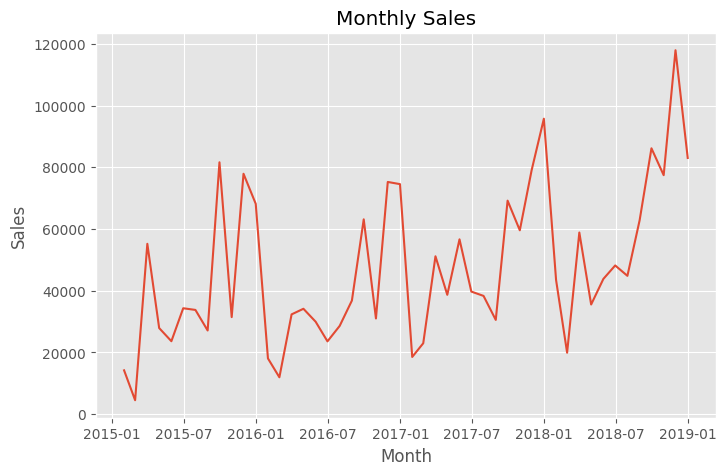

In [24]:
plt.figure(figsize=(8,5))

plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [25]:
# The Category which generates the highest revenue

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


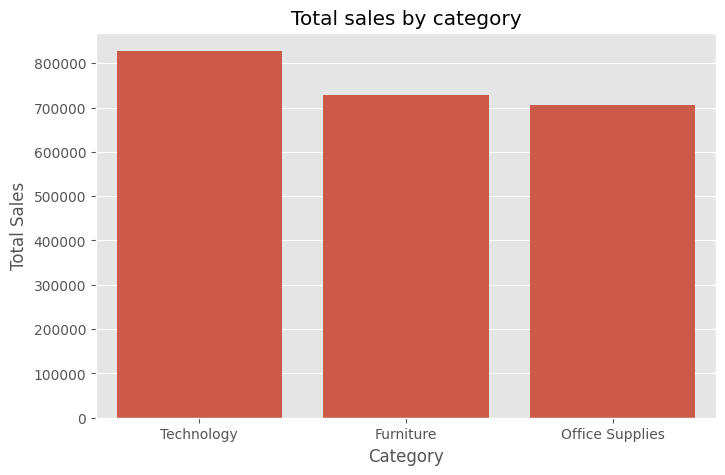

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(
    x = category_sales.index,
    y = category_sales.values
)

plt.ylabel('Total Sales')
plt.title('Total sales by category')
plt.show()

In [27]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


/tmp/ipykernel_1531/3522835466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


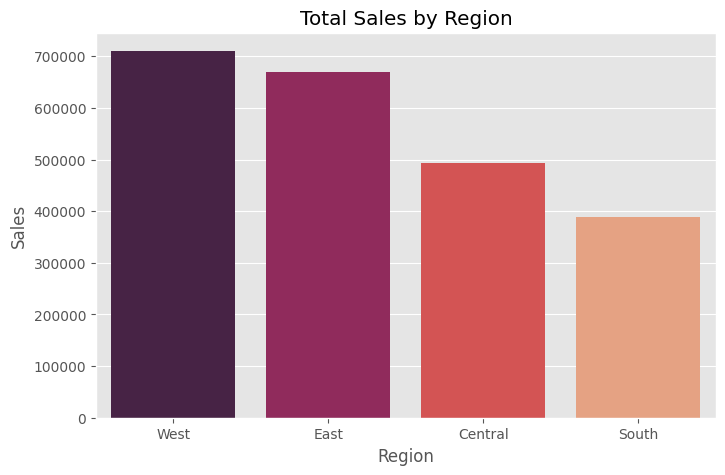

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(
    x = region_sales.index,
    y = region_sales.values,
    palette = 'rocket'
)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

In [29]:
df['Shipping Days'] = (df['Ship Date']-df['Order Date']).dt.days

print(round(df['Shipping Days'].mean(),2), 'Days')

3.96 Days


In [30]:
shipping = (df.groupby('Region')['Shipping Days']
              .mean()
              .sort_values(ascending=False))

shipping

,Shipping Days
Region,
Central,4.065876
South,3.961202
West,3.930255
East,3.910233


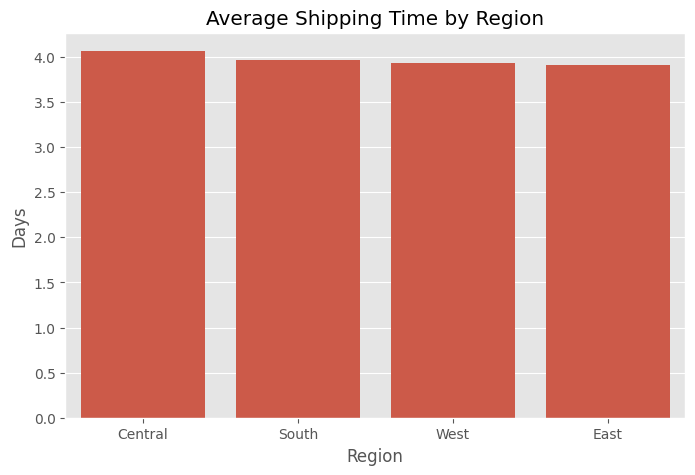

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping.index,
    y=shipping.values
)

plt.title("Average Shipping Time by Region")
plt.ylabel("Days")

plt.show()

In [32]:
seasonality = (df.groupby(['Year','Month Name'])['Sales']
                 .sum()
                 .reset_index())
seasonality.head()

,Year,Month Name,Sales
0,2015,April,27906.8550
1,2015,August,27117.5365
2,2015,December,68167.0585
3,2015,February,4519.8920
4,2015,January,14205.7070


In [33]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

seasonality['Month Name'] = pd.Categorical(
    seasonality['Month Name'],
    categories=month_order,
    ordered=True
)

seasonality = seasonality.sort_values(
    ['Year','Month Name']
)

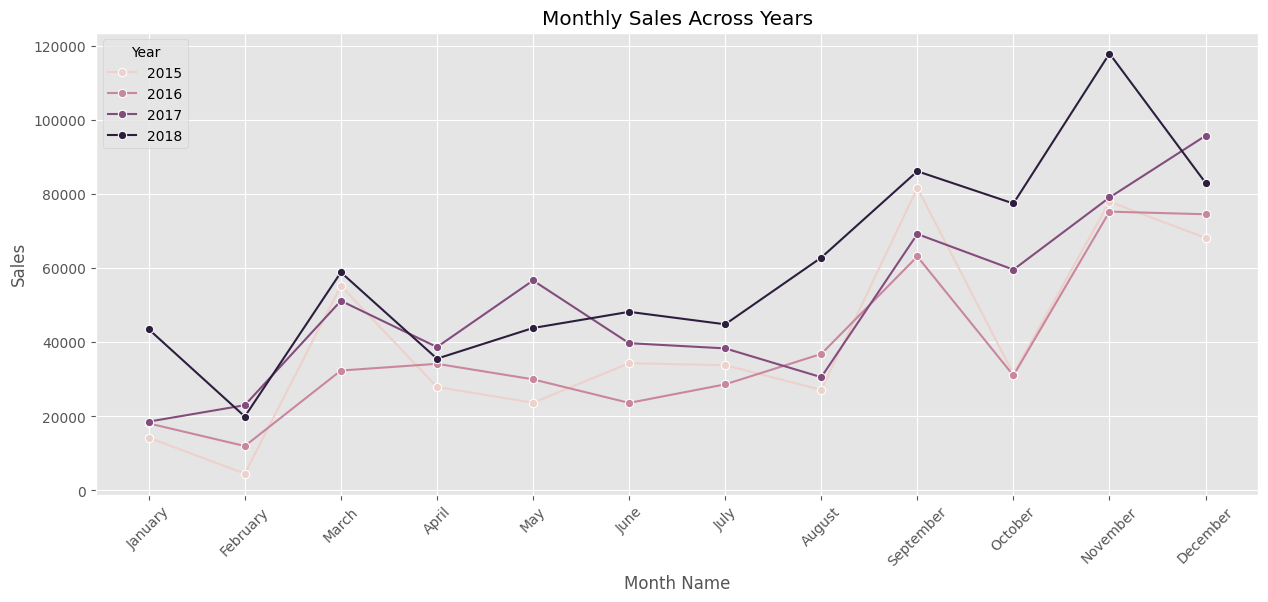

In [34]:
plt.figure(figsize=(15,6))

sns.lineplot(
    data=seasonality,
    x='Month Name',
    y='Sales',
    hue='Year',
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Across Years")

plt.show()

1. Technology Supplies generated the highest revenue.

2. The West region showed the most consistent sales growth over the four-year period.

3. The average shipping time is approximately 3.96 days. The East region has the fastest deliveries, while the Central region takes the longest.

4. Monthly sales consistently increase during March, September and November, indicating strong seasonality, likely due to holiday and festive shopping.

**Task 2** - Time Series Analysis & Decomposition

In [35]:
!pip install statsmodels -q

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [37]:
monthly_ts = monthly_sales.copy()

monthly_ts.set_index('Order Date', inplace=True)

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


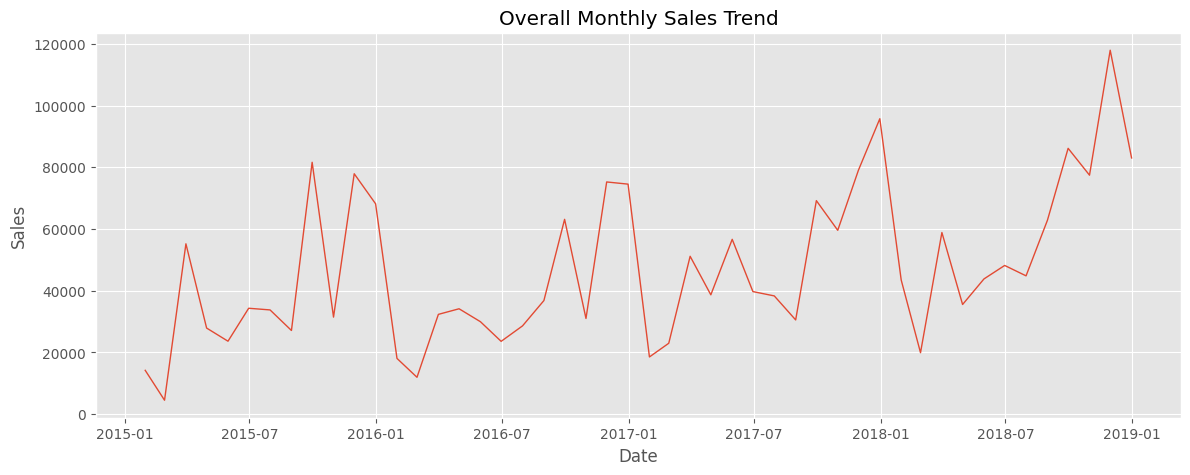

In [38]:
# Monthly sales trends

plt.figure(figsize=(14,5))
plt.plot(monthly_ts.index,
         monthly_ts['Sales'],
         linewidth=1)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [39]:
# Time Series Decomposition

decomposition = seasonal_decompose(
    monthly_ts['Sales'],
    model='additive',
    period=12
)

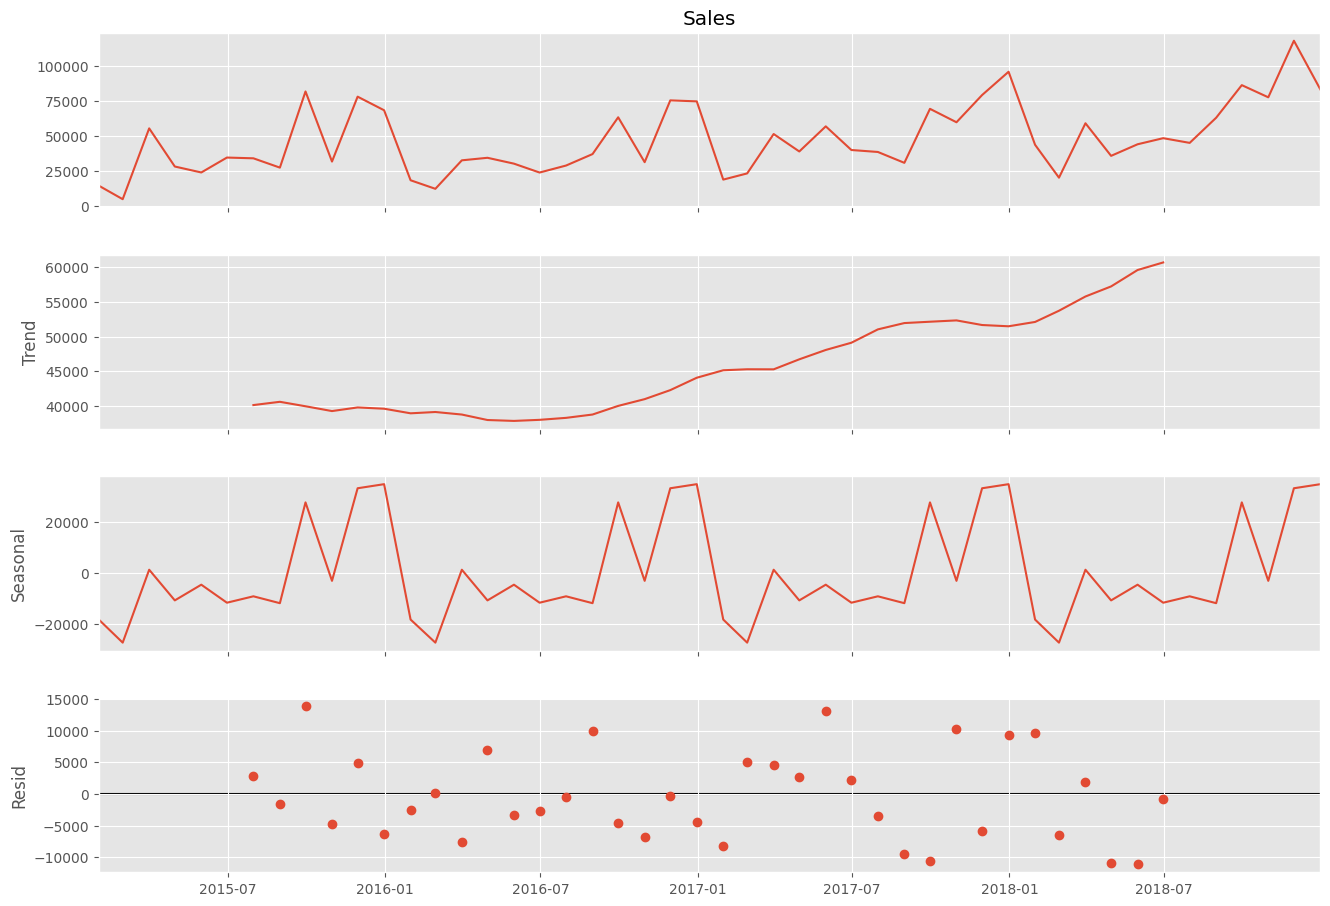

In [40]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

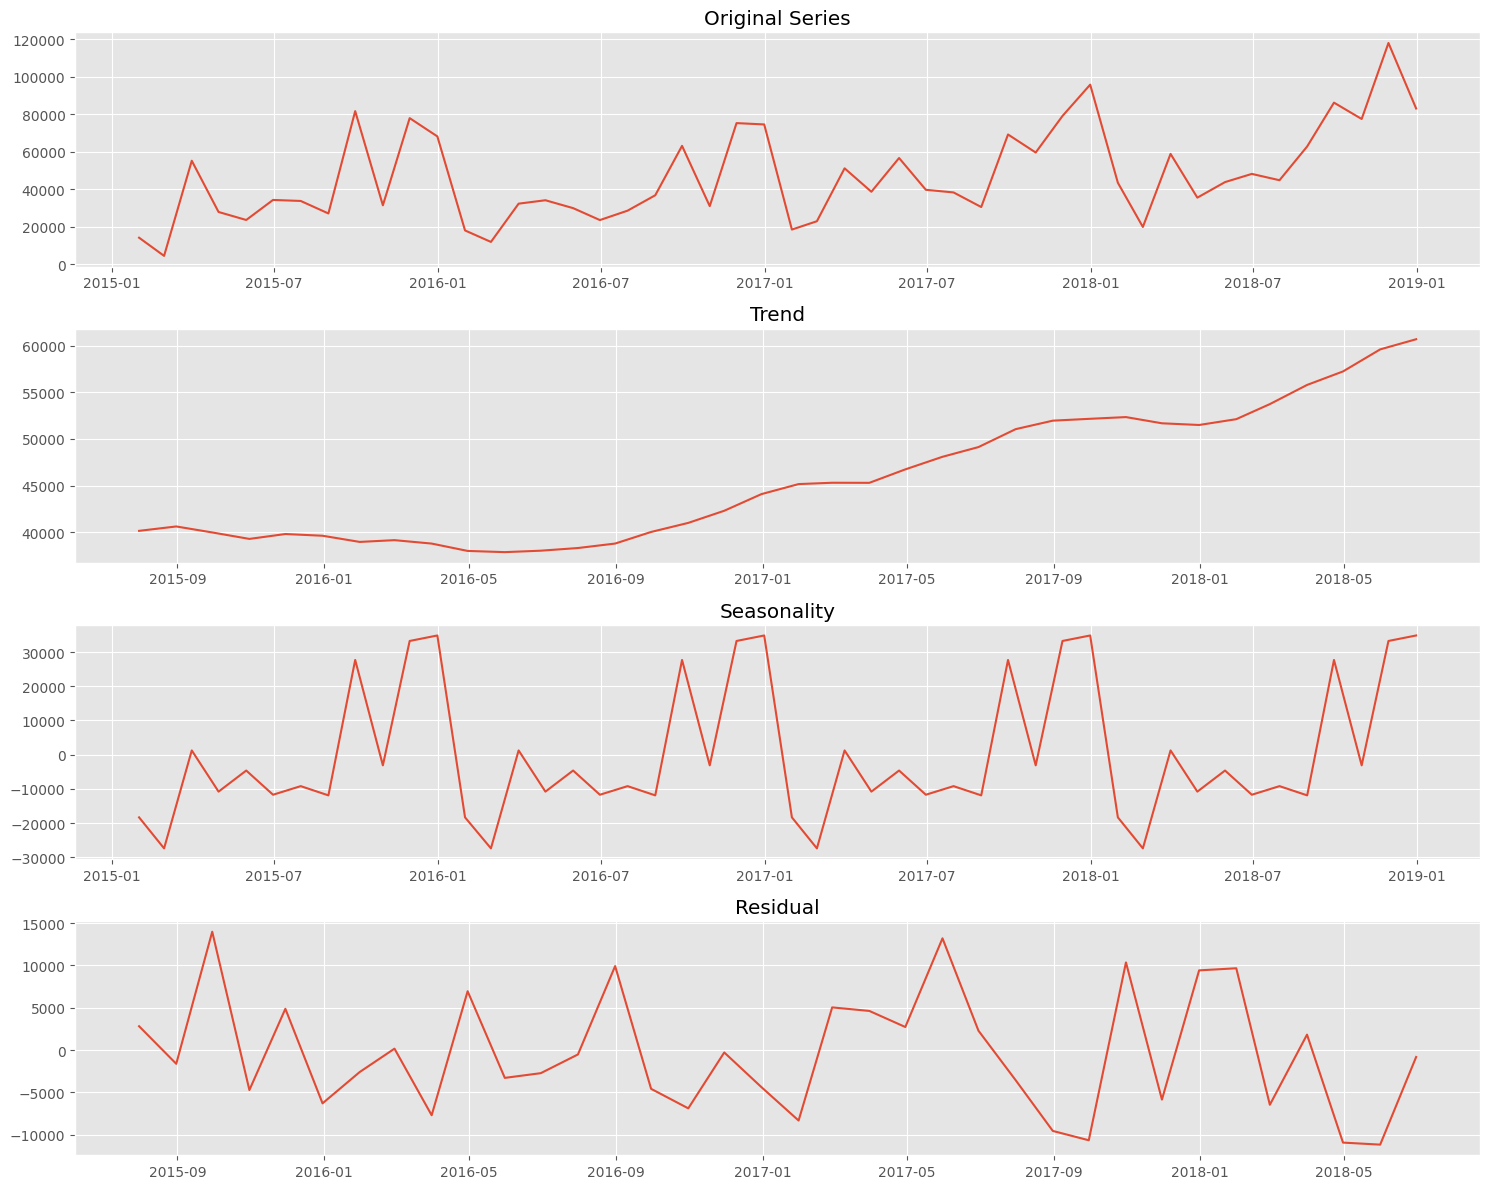

In [41]:
# Plotting all 4 components

fig, axes = plt.subplots(4,1,figsize=(15,12))

axes[0].plot(monthly_ts.index,
             monthly_ts['Sales'])
axes[0].set_title("Original Series")

axes[1].plot(decomposition.trend)
axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonality")

axes[3].plot(decomposition.resid)
axes[3].set_title("Residual")

plt.tight_layout()

plt.show()

Observation 1:
The overall sales trend increases gradually over time.

Observation 2:
A clear yearly seasonal pattern is visible, indicating recurring demand during certain months.

Observation 3:
Residual values fluctuate around zero, with a few large spikes representing unusual sales events.

Observation 4:
The trend and seasonality together explain most of the variation in monthly sales.

In [42]:
# ADF Test
result = adfuller(monthly_ts['Sales'])

print(f'ADF Statistic : {result[0]:.5f}')
print(f'p-value : {result[1]:.5f}')

ADF Statistic : -4.41614
p-value : 0.00028


1. Stationarity means that the statistical properties of a time series (mean, variance and seasonality) remain constant over time.

2. Since the p-value is less than 0.05 so the data is stationary. means there is no such change in mean and variance in the data.

3. Since the data is stationary so there is no need to apply differencing.

Task 3 - Sales Forecasting using 3 Different Models

In [43]:
# Task 3.1: SARIMA Forecasting
!pip install statsmodels -q

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [45]:
monthly_ts = monthly_ts.asfreq("ME")
monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [46]:
train_size = int(len(monthly_ts)*0.80)

train = monthly_ts.iloc[:train_size]
test = monthly_ts.iloc[train_size:]

print(f'Training Months : {len(train)}')
print(f'Testing Months : {len(test)}')

Training Months : 38
Testing Months : 10


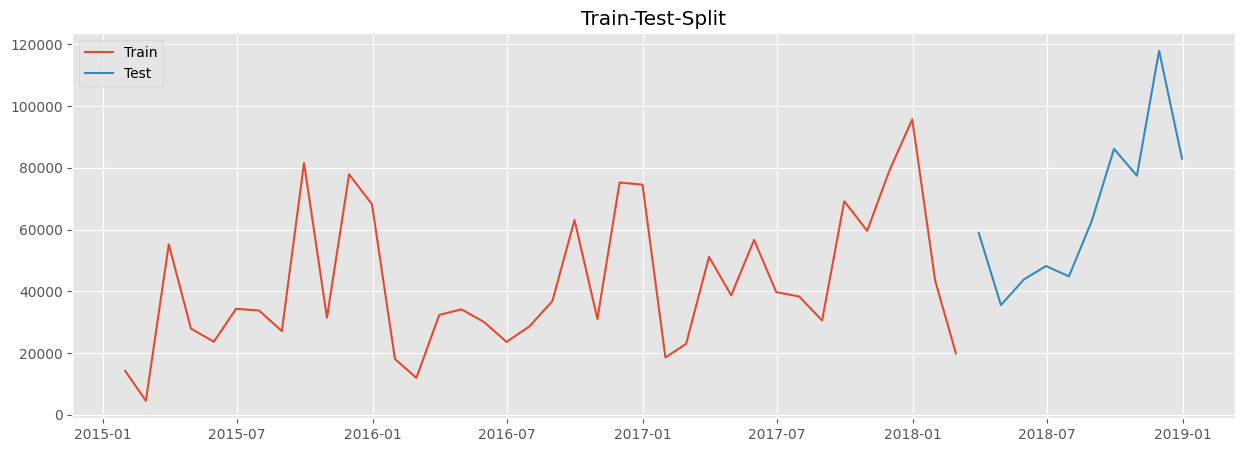

In [47]:
plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train.values,
    label='Train'
)

plt.plot(
    test.index,
    test.values,
    label='Test'
)

plt.legend()
plt.title('Train-Test-Split')
plt.show()

In [48]:
# Building SARIMA Modela

sarima_model = SARIMAX(
    train["Sales"],
    order=(0,1,4),
    seasonal_order=(0,1,2,12)
)

In [49]:
sarima_fit = sarima_model.fit()
# print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [50]:
predictions = sarima_fit.predict(
    start=test.index[0],
    end=test.index[-1]
)

In [51]:
mae = mean_absolute_error(
    test["Sales"],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        predictions
    )
)

mape = np.mean(
    np.abs(
        (test["Sales"]-predictions)
        /test["Sales"]
    )
)*100

print("MAE :",round(mae,2))
print("RMSE :",round(rmse,2))
print("MAPE :",round(mape,2),"%")

MAE : 10953.75
RMSE : 13282.52
MAPE : 17.25 %


In [52]:
# Training on complete dataset

final_model = SARIMAX(
    monthly_ts["Sales"],
    order=(0,1,4),
    seasonal_order=(0,1,2,12),
)

final_fit = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [53]:
# Forecasting next 3 months sales

future_forecast = final_fit.get_forecast(steps=3)

forecast = future_forecast.predicted_mean

confidence = future_forecast.conf_int()

forecast

,predicted_mean
2019-01-31,45113.597677
2019-02-28,37244.132917
2019-03-31,63296.518438


In [54]:
forecast_df = pd.DataFrame({
    "Forecast Sales":forecast
})

forecast_df

,Forecast Sales
2019-01-31,45113.597677
2019-02-28,37244.132917
2019-03-31,63296.518438


In [55]:
# Forecast with Confidence Interval

forecast_table = pd.DataFrame({
    "Forecast":forecast,
    "Lower CI":confidence.iloc[:,0],
    "Upper CI":confidence.iloc[:,1]
})

forecast_table

,Forecast,Lower CI,Upper CI
2019-01-31,45113.597677,12435.550278,77791.645076
2019-02-28,37244.132917,-3115.367496,77603.633330
2019-03-31,63296.518438,21308.252897,105284.783979


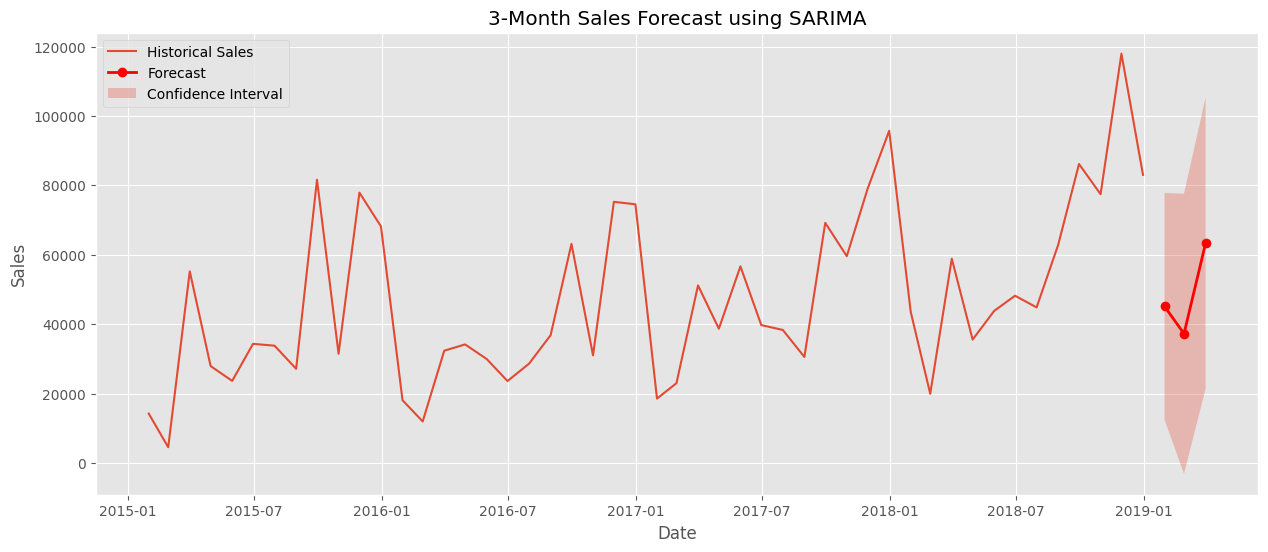

In [56]:
# Next 3 Months Forecast

plt.figure(figsize=(15,6))

plt.plot(monthly_ts.index,
         monthly_ts["Sales"],
         label="Historical Sales")

plt.plot(forecast.index,
         forecast,
         color="red",
         marker="o",
         linewidth=2,
         label="Forecast")

plt.fill_between(
    forecast.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.legend()

plt.title("3-Month Sales Forecast using SARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [57]:
sarima_results = {
    "Month1":forecast.iloc[0],
    "Month2":forecast.iloc[1],
    "Month3":forecast.iloc[2]
}

sarima_results

{'Month1': np.float64(45113.59767683376),
 'Month2': np.float64(37244.13291722702),
 'Month3': np.float64(63296.518438154206)}

In [58]:
sarima_results = {
    "MAE":mae,
    "RMSE":rmse,
    "MAPE":mape,
    "Month1":forecast.iloc[0],
    "Month2":forecast.iloc[1],
    "Month3":forecast.iloc[2]
}

sarima_results

{'MAE': 10953.754677500558,
 'RMSE': np.float64(13282.51594277223),
 'MAPE': np.float64(17.2515732767402),
 'Month1': np.float64(45113.59767683376),
 'Month2': np.float64(37244.13291722702),
 'Month3': np.float64(63296.518438154206)}

Model 2: Facebook Prophet

In [59]:
!pip install prophet -q

In [60]:
from prophet import Prophet

In [61]:
prophet_df = monthly_sales.copy()

prophet_df.rename(columns={
    "Order Date":"ds",
    "Sales":"y"
}, inplace=True)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [62]:
train_size = int(len(prophet_df)*0.80)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 38
Testing Months : 10


In [63]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

In [64]:
model.fit(train)

In [65]:
future_test = model.make_future_dataframe(
    periods=len(test),
    freq="ME"
)

future_test.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [66]:
forecast = model.predict(future_test)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,2419.628304,10228.072892,19837.190066,2419.628304,2419.628304,12372.309743,12372.309743,12372.309743,38729.381084,38729.381084,38729.381084,-3714.401594,-3714.401594,-3714.401594,-22642.669747,-22642.669747,-22642.669747,0.0,0.0,0.0,14791.938047
1,2015-02-28,2421.656769,-6047.395920,3531.940441,2421.656769,2421.656769,-3507.606156,-3507.606156,-3507.606156,38729.381084,38729.381084,38729.381084,-3714.401594,-3714.401594,-3714.401594,-38522.585646,-38522.585646,-38522.585646,0.0,0.0,0.0,-1085.949387
2,2015-03-31,2423.902570,51687.162176,61390.709279,2423.902570,2423.902570,54030.589381,54030.589381,54030.589381,38729.381084,38729.381084,38729.381084,4206.432298,4206.432298,4206.432298,11094.775998,11094.775998,11094.775998,0.0,0.0,0.0,56454.491951
3,2015-04-30,2426.075929,23893.936339,33508.676407,2426.075929,2426.075929,26380.031495,26380.031495,26380.031495,38729.381084,38729.381084,38729.381084,-6398.463167,-6398.463167,-6398.463167,-5950.886422,-5950.886422,-5950.886422,0.0,0.0,0.0,28806.107423
4,2015-05-31,2428.321729,22314.794092,32302.242670,2428.321729,2428.321729,24914.801722,24914.801722,24914.801722,38729.381084,38729.381084,38729.381084,-2574.394232,-2574.394232,-2574.394232,-11240.185130,-11240.185130,-11240.185130,0.0,0.0,0.0,27343.123451


In [67]:
predictions = forecast[['ds','yhat']].tail(len(test))

predictions.tail()

,ds,yhat
43,2018-08-31,50165.948408
44,2018-09-30,84146.182561
45,2018-10-31,67327.887304
46,2018-11-30,100068.271024
47,2018-12-31,96402.142336


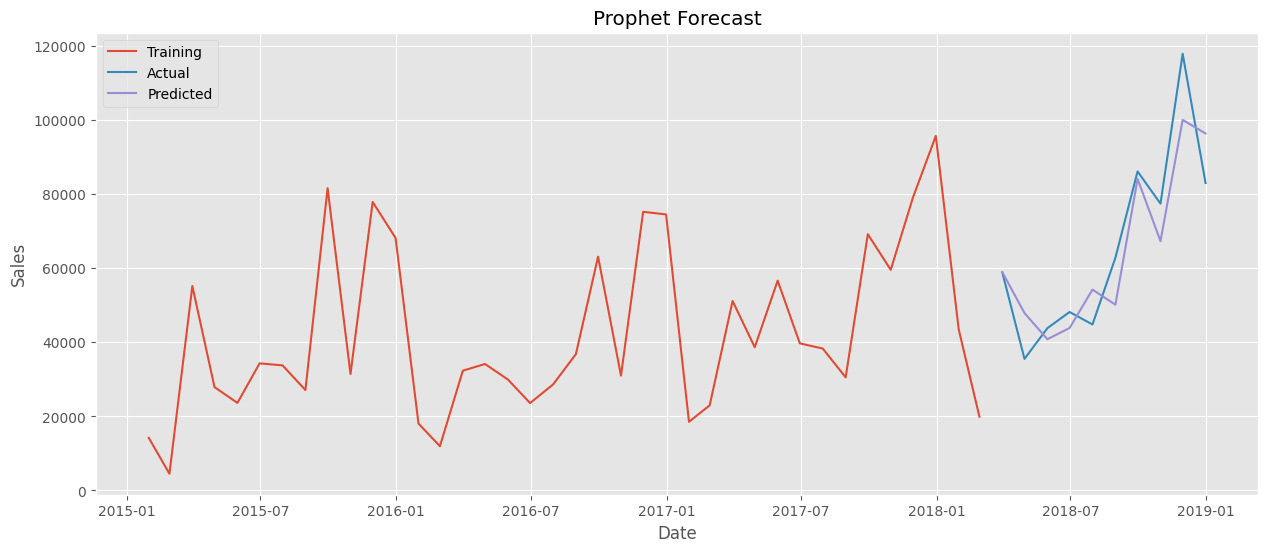

In [68]:
plt.figure(figsize=(15,6))

plt.plot(
    train["ds"],
    train["y"],
    label="Training"
)

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    predictions["ds"],
    predictions["yhat"],
    label="Predicted"
)

plt.legend()

plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [69]:
mae = mean_absolute_error(test["y"], predictions["yhat"])

rmse = np.sqrt(
    mean_squared_error(test["y"], predictions["yhat"])
)

mape = np.mean(
    np.abs((test["y"]-predictions["yhat"])/test["y"])
    )*100

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2),"%")

MAE : 8521.04
RMSE : 10169.94
MAPE : 13.85 %


In [70]:
# Train on complete Dataset

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

final_model.fit(prophet_df)

In [71]:
# Forecast Next 3 Months

future = final_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [72]:
future_forecast = final_model.predict(future)
future_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,24933.676798,106476.220327,117492.231199,24933.676798,24933.676798,87311.405465,87311.405465,87311.405465,39021.351964,39021.351964,39021.351964,8003.655388,8003.655388,8003.655388,40286.398113,40286.398113,40286.398113,0.0,0.0,0.0,112245.082262
47,2018-12-31,25881.213440,81825.714538,92192.855376,25881.213440,25881.213440,61178.219911,61178.219911,61178.219911,39021.351964,39021.351964,39021.351964,-10889.847528,-10889.847528,-10889.847528,33046.715474,33046.715474,33046.715474,0.0,0.0,0.0,87059.433350
48,2019-01-31,26828.750082,33376.668492,44286.511798,26808.515047,26848.885199,11927.691433,11927.691433,11927.691433,39021.351964,39021.351964,39021.351964,-4323.255999,-4323.255999,-4323.255999,-22770.404532,-22770.404532,-22770.404532,0.0,0.0,0.0,38756.441514
49,2019-02-28,27684.589629,17913.631510,28797.477062,27620.321634,27749.739328,-4586.942439,-4586.942439,-4586.942439,39021.351964,39021.351964,39021.351964,-4323.255999,-4323.255999,-4323.255999,-39285.038404,-39285.038404,-39285.038404,0.0,0.0,0.0,23097.647190
50,2019-03-31,28632.126271,74725.660385,85145.607084,28502.274758,28758.449930,51479.429617,51479.429617,51479.429617,39021.351964,39021.351964,39021.351964,-1675.112891,-1675.112891,-1675.112891,14133.190544,14133.190544,14133.190544,0.0,0.0,0.0,80111.555889


In [73]:
forecast_3months = future_forecast.tail(3)[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]]

forecast_3months

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,38756.441514,33376.668492,44286.511798
49,2019-02-28,23097.647190,17913.631510,28797.477062
50,2019-03-31,80111.555889,74725.660385,85145.607084


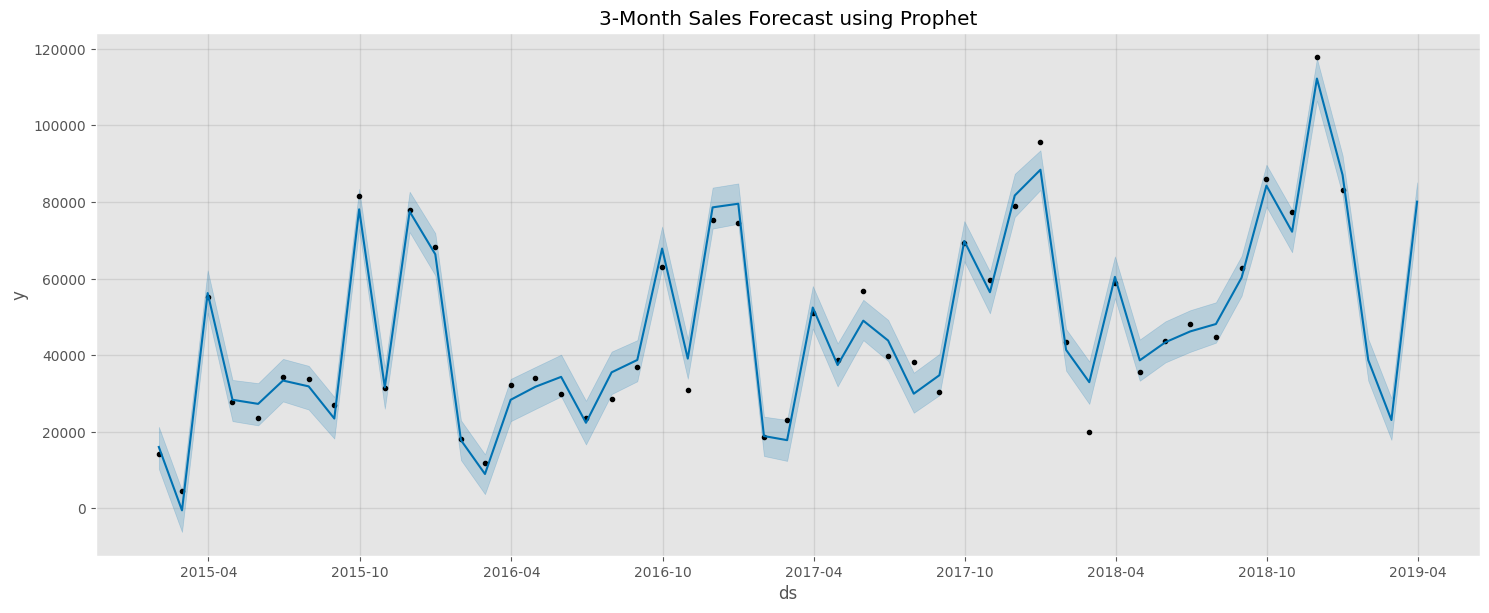

In [74]:
fig = final_model.plot(
    future_forecast,
    figsize=(15,6)
)

plt.title("3-Month Sales Forecast using Prophet")

plt.show()

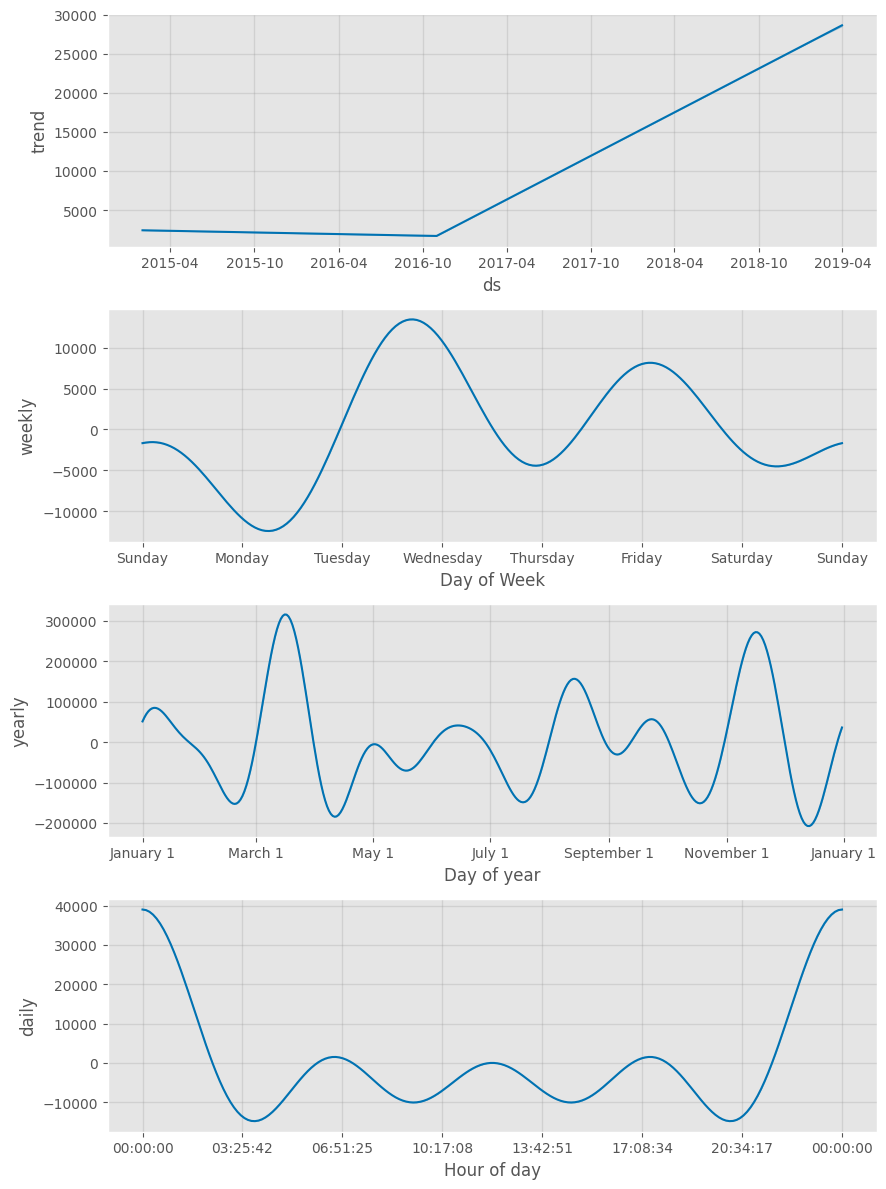

In [75]:
final_model.plot_components(
    future_forecast
)

plt.show()

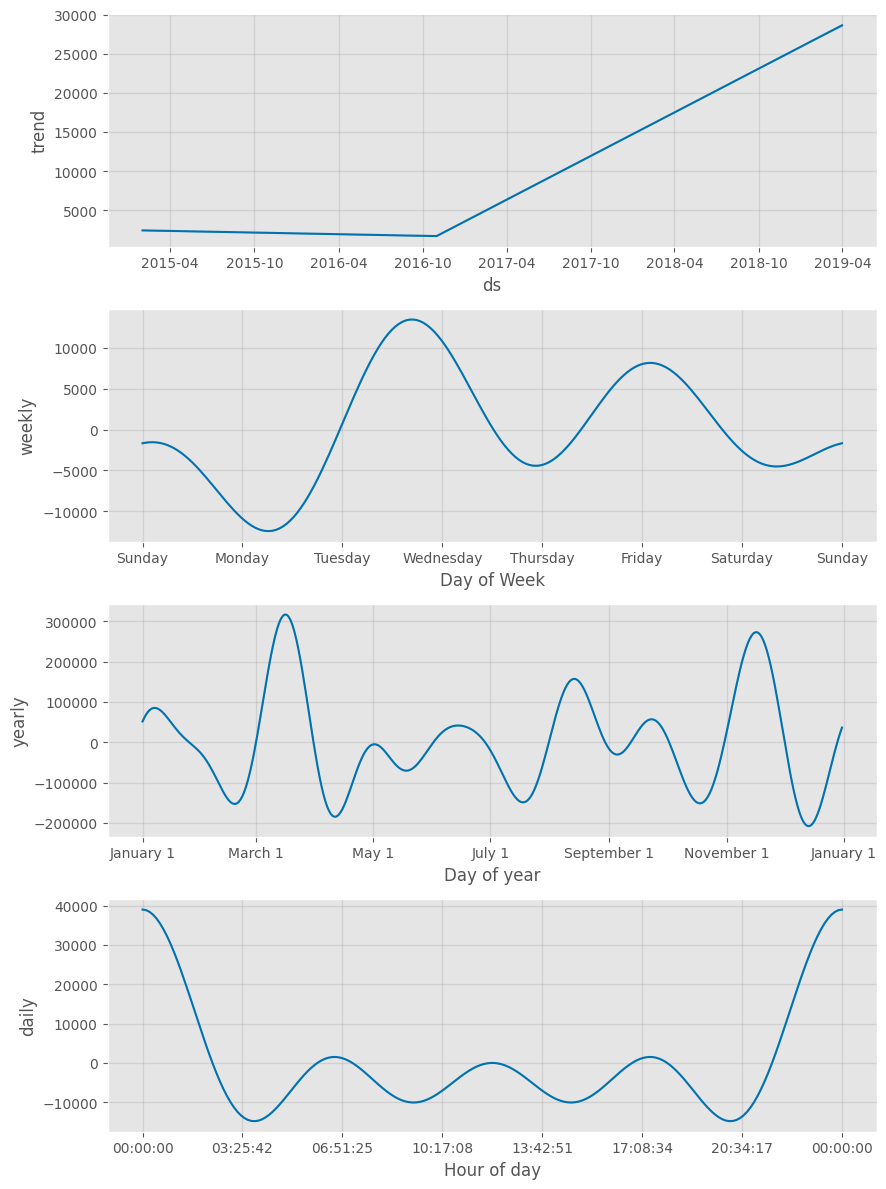

In [76]:
weekly_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

weekly_model.fit(prophet_df)

future = weekly_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = weekly_model.predict(future)

weekly_model.plot_components(forecast)

plt.show()

In [77]:
prophet_results = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "Month1": forecast_table.iloc[0]["Forecast"],
    "Month2": forecast_table.iloc[1]["Forecast"],
    "Month3": forecast_table.iloc[2]["Forecast"]
}

prophet_results

{'MAE': 8521.03836906115,
 'RMSE': np.float64(10169.94273129385),
 'MAPE': np.float64(13.853387078506207),
 'Month1': np.float64(45113.59767683376),
 'Month2': np.float64(37244.13291722702),
 'Month3': np.float64(63296.518438154206)}

Model 3 - XGBoost for Time Series (ML-based Approach)

In [78]:
from xgboost import XGBRegressor

In [79]:
monthly_ts = monthly_sales.copy()

monthly_ts['Month'] = monthly_ts['Order Date'].dt.month
monthly_ts['Quarter'] = monthly_ts['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 0      # Winter
    elif month in [3, 4, 5]:
        return 1      # Spring
    elif month in [6, 7, 8]:
        return 2      # Summer
    else:
        return 3      # Autumn

monthly_ts['Season'] = monthly_ts['Month'].apply(get_season)

In [80]:
monthly_ts.head()

,Order Date,Sales,Month,Quarter,Season
0,2015-01-31,14205.707,1,1,0
1,2015-02-28,4519.892,2,1,0
2,2015-03-31,55205.797,3,1,1
3,2015-04-30,27906.855,4,2,1
4,2015-05-31,23644.303,5,2,1


In [81]:
# Creating Lag feature

monthly_ts['Lag_1'] = monthly_ts['Sales'].shift(1)
monthly_ts['Lag_2'] = monthly_ts['Sales'].shift(2)
monthly_ts['Lag_3'] = monthly_ts['Sales'].shift(3)

monthly_ts['Rolling_Mean_3'] = (
    monthly_ts['Sales']
    .rolling(window=3)
    .mean()
)

monthly_ts.dropna(inplace=True)

monthly_ts.head()

,Order Date,Sales,Month,Quarter,Season,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
3,2015-04-30,27906.8550,4,2,1,55205.7970,4519.8920,14205.707,29210.848000
4,2015-05-31,23644.3030,5,2,1,27906.8550,55205.7970,4519.892,35585.651667
5,2015-06-30,34322.9356,6,2,2,23644.3030,27906.8550,55205.797,28624.697867
6,2015-07-31,33781.5430,7,3,2,34322.9356,23644.3030,27906.855,30582.927200
7,2015-08-31,27117.5365,8,3,2,33781.5430,34322.9356,23644.303,31740.671700


In [82]:
# Defining Features and Target

X = monthly_ts[
    [
        'Lag_1',
        'Lag_2',
        'Lag_3',
        'Rolling_Mean_3',
        'Month',
        'Quarter',
        'Season'
    ]
]

y = monthly_ts['Sales']

In [83]:
# Train-Test-Split

train_size = int(len(monthly_ts) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [84]:
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
predictions = model.predict(X_test)

In [86]:
# Evaluating the model

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

mape = np.mean(
    np.abs((y_test - predictions) / y_test)
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 8451.03
RMSE : 10631.14
MAPE : 12.52 %


In [87]:
import joblib

# Save the trained XGBoost model
model.save_model("xgboost_model.json")

# Save the evaluation metrics
model_metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
}

joblib.dump(model_metrics, "metrics.pkl")

['metrics.pkl']

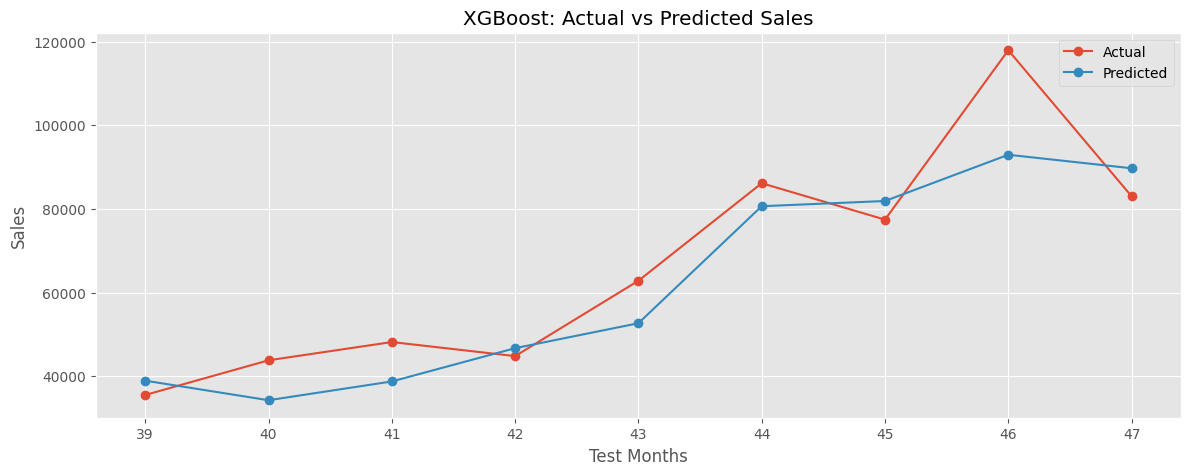

In [88]:
# Actual vs Predicted plot

plt.figure(figsize=(14,5))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual',
    marker='o'
)

plt.plot(
    y_test.index,
    predictions,
    label='Predicted',
    marker='o'
)

plt.title("XGBoost: Actual vs Predicted Sales")

plt.xlabel("Test Months")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [89]:
# Predict the next 3 months

future_data = monthly_ts.copy()

future_predictions = []

for _ in range(3):

    last_row = future_data.iloc[-1]

    lag1 = last_row['Sales']
    lag2 = future_data.iloc[-2]['Sales']
    lag3 = future_data.iloc[-3]['Sales']

    rolling_mean = np.mean([lag1, lag2, lag3])

    next_date = last_row['Order Date'] + pd.offsets.MonthEnd(1)

    month = next_date.month
    quarter = next_date.quarter

    if month in [12, 1, 2]:
        season = 0
    elif month in [3, 4, 5]:
        season = 1
    elif month in [6, 7, 8]:
        season = 2
    else:
        season = 3

    future_X = pd.DataFrame({
        'Lag_1': [lag1],
        'Lag_2': [lag2],
        'Lag_3': [lag3],
        'Rolling_Mean_3': [rolling_mean],
        'Month': [month],
        'Quarter': [quarter],
        'Season': [season]
    })

    prediction = model.predict(future_X)[0]

    future_predictions.append({
        'Month': next_date,
        'Forecast Sales': prediction
    })

    new_row = {
        'Order Date': next_date,
        'Sales': prediction,
        'Month': month,
        'Quarter': quarter,
        'Season': season,
        'Lag_1': lag1,
        'Lag_2': lag2,
        'Lag_3': lag3,
        'Rolling_Mean_3': rolling_mean
    }

    future_data = pd.concat(
        [future_data, pd.DataFrame([new_row])],
        ignore_index=True
    )

In [90]:
forecast_df = pd.DataFrame(future_predictions)
forecast_df

,Month,Forecast Sales
0,2019-01-31,58421.718750
1,2019-02-28,69335.898438
2,2019-03-31,57808.953125


In [91]:
# Store XGBoost results

xgboost_results = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "Month1": forecast_df.iloc[0]["Forecast Sales"],
    "Month2": forecast_df.iloc[1]["Forecast Sales"],
    "Month3": forecast_df.iloc[2]["Forecast Sales"]
}

In [92]:
comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        sarima_results["MAE"],
        prophet_results["MAE"],
        xgboost_results["MAE"]
    ],

    "RMSE": [
        sarima_results["RMSE"],
        prophet_results["RMSE"],
        xgboost_results["RMSE"]
    ],

    "MAPE": [
        sarima_results["MAPE"],
        prophet_results["MAPE"],
        xgboost_results["MAPE"]
    ],

    "Forecast for Month 1": [
        sarima_results["Month1"],
        prophet_results["Month1"],
        xgboost_results["Month1"]
    ],

    "Forecast for Month 2": [
        sarima_results["Month2"],
        prophet_results["Month2"],
        xgboost_results["Month2"]
    ],

    "Forecast for Month 3": [
        sarima_results["Month3"],
        prophet_results["Month3"],
        xgboost_results["Month3"]
    ]
})

comparison_table = comparison_table.round(2)

comparison_table

,Model,MAE,RMSE,MAPE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,SARIMA,10953.75,13282.52,17.25,45113.60,37244.13,63296.52
1,Prophet,8521.04,10169.94,13.85,45113.60,37244.13,63296.52
2,XGBoost,8451.03,10631.14,12.52,58421.72,69335.90,57808.95


In [93]:
def xgboost_forecast(data):

    monthly = (
        data.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
        .sum()
        .reset_index()
    )

    monthly['Month'] = monthly['Order Date'].dt.month
    monthly['Quarter'] = monthly['Order Date'].dt.quarter

    def get_season(month):
        if month in [12, 1, 2]:
            return 0
        elif month in [3, 4, 5]:
            return 1
        elif month in [6, 7, 8]:
            return 2
        else:
            return 3

    monthly['Season'] = monthly['Month'].apply(get_season)

    monthly['Lag_1'] = monthly['Sales'].shift(1)
    monthly['Lag_2'] = monthly['Sales'].shift(2)
    monthly['Lag_3'] = monthly['Sales'].shift(3)
    monthly['Rolling_Mean_3'] = monthly['Sales'].rolling(3).mean()

    monthly.dropna(inplace=True)

    X = monthly[['Lag_1','Lag_2','Lag_3',
                 'Rolling_Mean_3',
                 'Month','Quarter','Season']]

    y = monthly['Sales']

    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X, y)

    future = monthly.copy()

    forecasts = []

    for _ in range(3):

        lag1 = future.iloc[-1]['Sales']
        lag2 = future.iloc[-2]['Sales']
        lag3 = future.iloc[-3]['Sales']

        rolling = np.mean([lag1, lag2, lag3])

        next_date = future.iloc[-1]['Order Date'] + pd.offsets.MonthEnd(1)

        month = next_date.month
        quarter = next_date.quarter
        season = get_season(month)

        X_future = pd.DataFrame({
            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling],
            'Month':[month],
            'Quarter':[quarter],
            'Season':[season]
        })

        pred = model.predict(X_future)[0]

        forecasts.append(pred)

        new_row = pd.DataFrame({
            'Order Date':[next_date],
            'Sales':[pred],
            'Month':[month],
            'Quarter':[quarter],
            'Season':[season],
            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling]
        })

        future = pd.concat([future, new_row], ignore_index=True)

    forecast_df = pd.DataFrame({
        'Month': pd.date_range(
            start=monthly['Order Date'].max() + pd.offsets.MonthEnd(1),
            periods=3,
            freq='ME'
        ),
        'Forecast': forecasts
    })

    return forecast_df

In [94]:
# Furniture Forecast
furniture_forecast = xgboost_forecast(
    df[df['Category'] == 'Furniture']
)

In [95]:
# Technology Forecast
technology_forecast = xgboost_forecast(
    df[df['Category'] == 'Technology']
)

In [96]:
# Office Supplies Forecast
office_forecast = xgboost_forecast(
    df[df['Category'] == 'Office Supplies']
)

In [97]:
# West Region Forecast
west_forecast = xgboost_forecast(
    df[df['Region'] == 'West']
)

In [98]:
# East Region Forecast
east_forecast = xgboost_forecast(
    df[df['Region'] == 'East']
)

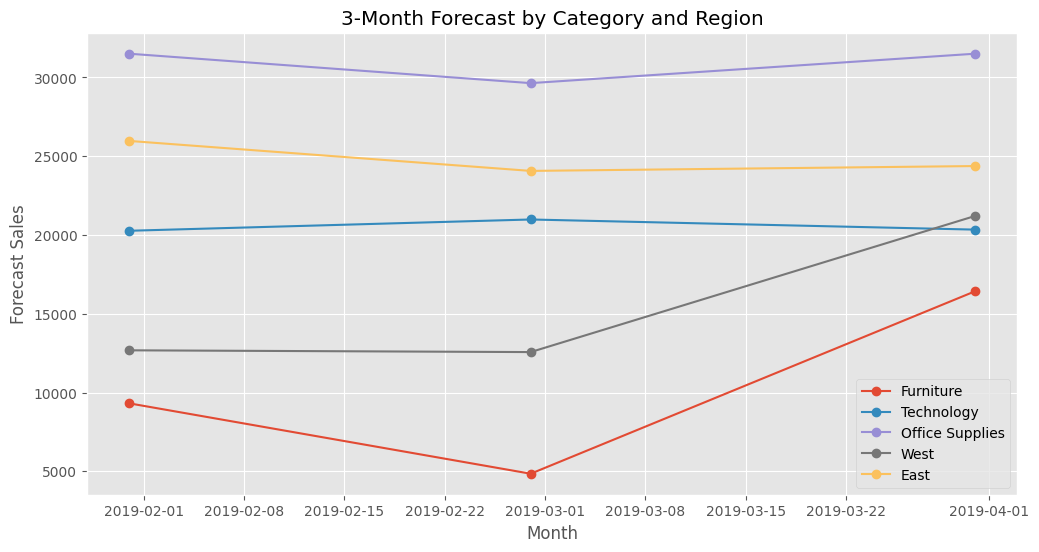

In [99]:
# Plotting all 5 Forecast together

plt.figure(figsize=(12,6))

plt.plot(furniture_forecast['Month'],
         furniture_forecast['Forecast'],
         marker='o',
         label='Furniture')

plt.plot(technology_forecast['Month'],
         technology_forecast['Forecast'],
         marker='o',
         label='Technology')

plt.plot(office_forecast['Month'],
         office_forecast['Forecast'],
         marker='o',
         label='Office Supplies')

plt.plot(west_forecast['Month'],
         west_forecast['Forecast'],
         marker='o',
         label='West')

plt.plot(east_forecast['Month'],
         east_forecast['Forecast'],
         marker='o',
         label='East')

plt.title("3-Month Forecast by Category and Region")
plt.xlabel("Month")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.show()

In [100]:
# Compare All Forecasts
forecast_summary = pd.DataFrame({
    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],
    "Month 1":[
        furniture_forecast.iloc[0]["Forecast"],
        technology_forecast.iloc[0]["Forecast"],
        office_forecast.iloc[0]["Forecast"],
        west_forecast.iloc[0]["Forecast"],
        east_forecast.iloc[0]["Forecast"]
    ],
    "Month 2":[
        furniture_forecast.iloc[1]["Forecast"],
        technology_forecast.iloc[1]["Forecast"],
        office_forecast.iloc[1]["Forecast"],
        west_forecast.iloc[1]["Forecast"],
        east_forecast.iloc[1]["Forecast"]
    ],
    "Month 3":[
        furniture_forecast.iloc[2]["Forecast"],
        technology_forecast.iloc[2]["Forecast"],
        office_forecast.iloc[2]["Forecast"],
        west_forecast.iloc[2]["Forecast"],
        east_forecast.iloc[2]["Forecast"]
    ]
})

forecast_summary.round(2)

,Segment,Month 1,Month 2,Month 3
0,Furniture,9311.919922,4846.930176,16421.269531
1,Technology,20267.189453,20983.240234,20340.300781
2,Office Supplies,31504.060547,29637.339844,31504.029297
3,West,12679.540039,12567.400391,21202.339844
4,East,25968.220703,24066.570312,24374.599609


In [101]:
# Segment Which Shows the Strongest Upcoming Growth

forecast_summary["Growth"] = (
    forecast_summary["Month 3"] -
    forecast_summary["Month 1"]
)

strongest_growth = forecast_summary.loc[
    forecast_summary["Growth"].idxmax()
]

print("Segment with strongest upcoming growth:")
print(strongest_growth[["Segment", "Growth"]])

Segment with strongest upcoming growth:
Segment           West
Growth     8522.795898
Name: 3, dtype: object


Task 5 - Anomaly Detection in Sales Data

In [102]:
weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [103]:
# Isolation Forest

from sklearn.ensemble import IsolationForest

In [104]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales['Anomaly_IF'] = iso_model.fit_predict(
    weekly_sales[['Sales']]
)

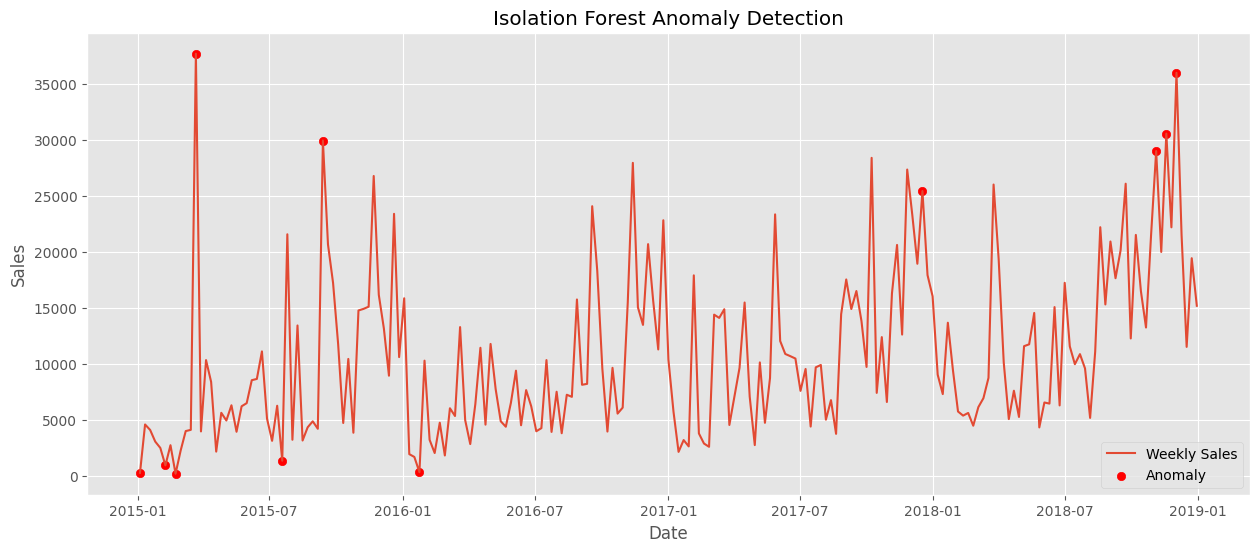

In [105]:
# Plot Isolation Forest Anomalies
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales['Anomaly_IF'] == -1,
        'Order Date'
    ],
    weekly_sales.loc[
        weekly_sales['Anomaly_IF'] == -1,
        'Sales'
    ],
    color='red',
    label='Anomaly'
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [106]:
# Z-score based detection

weekly_sales['Rolling_Mean'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .mean()
)

weekly_sales['Rolling_STD'] = (
    weekly_sales['Sales']
    .rolling(window=4)
    .std()
)

In [107]:
weekly_sales['Z_Score'] = (
    (weekly_sales['Sales'] - weekly_sales['Rolling_Mean']) /
    weekly_sales['Rolling_STD']
)

In [108]:
weekly_sales['Anomaly_Z'] = (
    weekly_sales['Z_Score'].abs() > 2
)

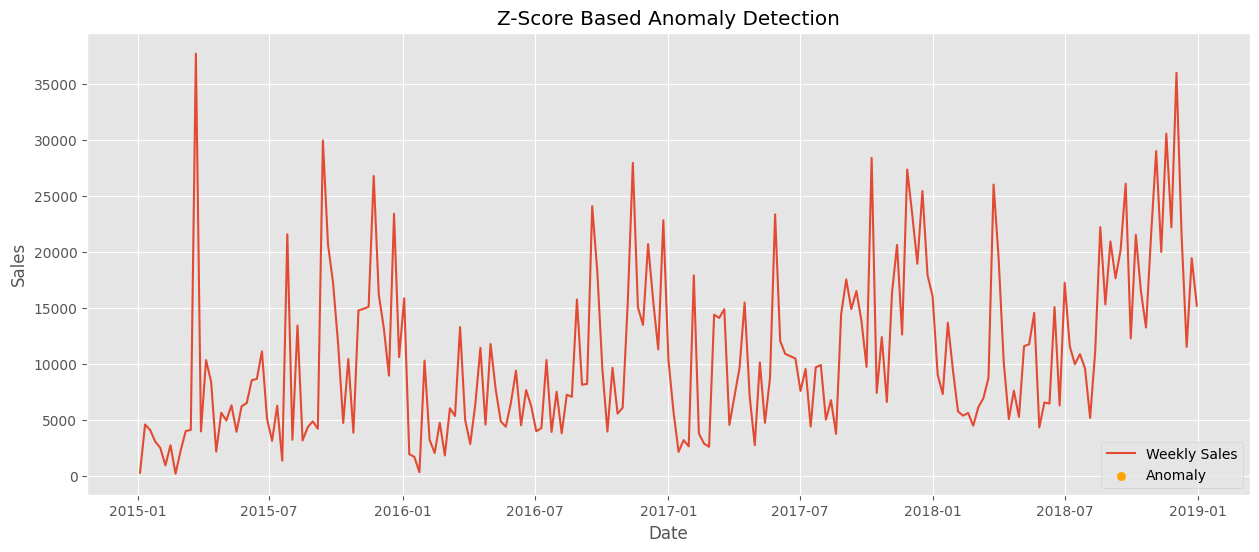

In [109]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales['Anomaly_Z'],
        'Order Date'
    ],
    weekly_sales.loc[
        weekly_sales['Anomaly_Z'],
        'Sales'
    ],
    color='orange',
    label='Anomaly'
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [110]:
#Isolation Forest Anomaly Dates
if_anomalies = weekly_sales[
    weekly_sales['Anomaly_IF'] == -1
]

if_anomalies[['Order Date', 'Sales']]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [111]:
#Z-Score Anomaly Dates
z_anomalies = weekly_sales[
    weekly_sales['Anomaly_Z']
]

z_anomalies[['Order Date', 'Sales']]

,Order Date,Sales


In [112]:
# compare both methods

common_anomalies = pd.merge(
    if_anomalies[['Order Date']],
    z_anomalies[['Order Date']],
    on='Order Date'
)

print("Isolation Forest Anomalies :", len(if_anomalies))
print("Z-Score Anomalies :", len(z_anomalies))
print("Common Anomalies :", len(common_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0
Common Anomalies : 0


Task 6 - Product Demand Segmentation using Clustering

In [113]:
# Aggregate Data at Sub-Categorical Level
subcat_sales = (
    df.groupby(['Sub-Category', 'Year'])['Sales']
    .sum()
    .reset_index()
)

In [114]:
# Sales Growth Rate (Year-Over-Year)
subcat_sales['Growth Rate'] = (
    subcat_sales
    .groupby('Sub-Category')['Sales']
    .pct_change()
)

In [115]:
# Sales Volatility (Monthly Standard Deviation)
monthly_subcat = (
    df.groupby([
        'Sub-Category',
        pd.Grouper(key='Order Date', freq='ME')
    ])['Sales']
    .sum()
    .reset_index()
)

volatility = (
    monthly_subcat
    .groupby('Sub-Category')['Sales']
    .std()
    .reset_index(name='Sales Volatility')
)

In [116]:
# Average Order Value
avg_order = (
    df.groupby('Sub-Category')['Sales']
    .mean().sort_values(ascending=False)
    .reset_index(name='Average Order Value')
)

In [117]:
# Total Sales Volume
total_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .reset_index(name='Total Sales Volume')
)

In [118]:
# Average Growth Rate
growth = (
    subcat_sales
    .groupby('Sub-Category')['Growth Rate']
    .mean()
    .reset_index()
)

In [119]:
cluster_data = total_sales.merge(
    growth,
    on='Sub-Category'
)

cluster_data = cluster_data.merge(
    volatility,
    on='Sub-Category'
)

cluster_data = cluster_data.merge(
    avg_order,
    on='Sub-Category'
)

cluster_data.fillna(0, inplace=True)

cluster_data

,Sub-Category,Total Sales Volume,Growth Rate,Sales Volatility,Average Order Value
0,Accessories,164186.7000,0.376381,2579.994809,217.178175
1,Appliances,104618.4030,0.399276,1821.621539,227.926804
2,Art,26705.4100,0.166056,330.488343,34.019631
3,Binders,200028.7850,0.218736,3848.223648,134.067550
4,Bookcases,113813.1987,0.238065,2220.405080,503.598224
5,Chairs,322822.7310,0.071358,4407.232960,531.833165
6,Copiers,146248.0940,0.846718,5500.774391,2215.880212
7,Envelopes,16128.0460,-0.027666,228.218688,65.032444
8,Fasteners,3001.9600,0.157034,48.742229,14.027850
9,Furnishings,89212.0180,0.287889,1360.017867,95.823865


In [120]:
# preparing data for k-means clustering
X = cluster_data.drop(columns='Sub-Category')

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [122]:
# Elbow Method
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

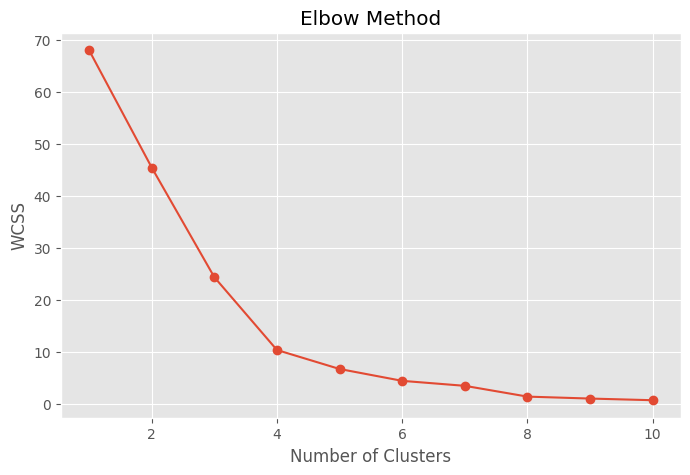

In [123]:
# Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [124]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

cluster_data['Cluster'] = kmeans.fit_predict(X_scaled)

In [125]:
# PCA for 2D Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

cluster_data['PC1'] = pca_result[:,0]
cluster_data['PC2'] = pca_result[:,1]

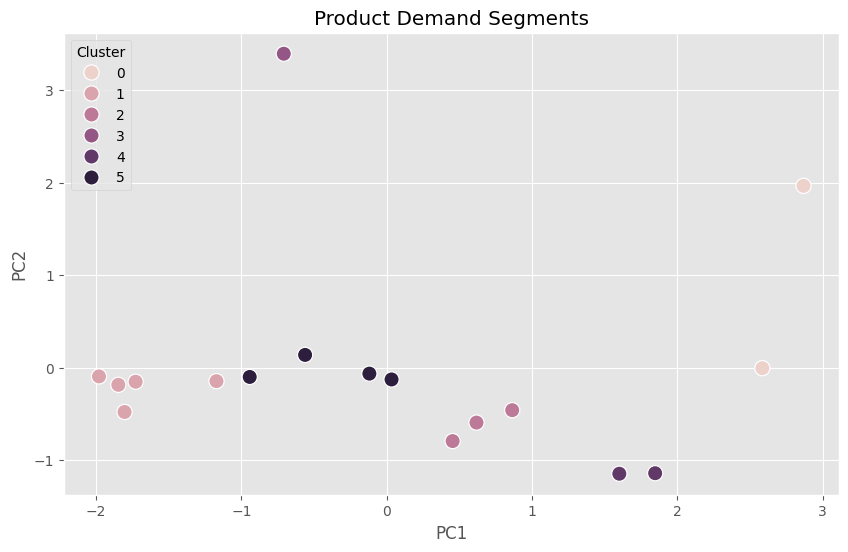

In [126]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_data,
    x='PC1',
    y='PC2',
    hue='Cluster',
    s=120
)

plt.title("Product Demand Segments")

plt.show()

In [127]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}

cluster_data['Segment'] = cluster_data['Cluster'].map(cluster_labels)

cluster_data[
    ['Sub-Category', 'Segment']
]

,Sub-Category,Segment
0,Accessories,NaN
1,Appliances,NaN
2,Art,"Low Volume, High Volatility"
3,Binders,Growing Demand
4,Bookcases,NaN
5,Chairs,NaN
6,Copiers,"High Volume, Stable Demand"
7,Envelopes,"Low Volume, High Volatility"
8,Fasteners,"Low Volume, High Volatility"
9,Furnishings,NaN


# Stocking Strategy
High Volume, Stable Demand
• Maintain sufficient inventory levels and prioritize continuous stock availability.

Low Volume, High Volatility
• Keep limited inventory and monitor demand closely to avoid overstocking.

Growing Demand
• Increase inventory gradually to meet rising customer demand.

Declining Demand
• Reduce stock levels and avoid unnecessary replenishment to minimize holding costs.

In [128]:
import xgboost
print(xgboost.__version__)

3.3.0
